# Dependencies

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load MTR Data

In [3]:
data = pd.read_csv('MTR_Data/mtr_data.csv')

distance_upper80 = data["Total Distance (km)"].quantile(0.8)
distance_lower10 = data["Total Distance (km)"].quantile(0.1)
price_upper90 = data["Fare (HKD)"].quantile(0.9)
price_lower1= data["Fare (HKD)"].quantile(0.01)
data = data[(data['Total Distance (km)'] >= distance_lower10) & 
            (data['Total Distance (km)'] <= distance_upper80) &
            (data['Fare (HKD)'] >= price_lower1) &
            (data['Fare (HKD)'] <= price_upper90)]

In [4]:
# correlation of feature 'No of Stops' and 'Total Distance (km)' 
data[['No. of Stations', 'Total Distance (km)']].corr(method='pearson')
data[(data['No. of Stations']<=5) & (data['Fare (HKD)']>=12)]

,Origin Station,Origin Station Number,Origin Latitude,Origin Longitude,Origin Constituency,Origin District,Destination Station,Destination Station Number,Destination Latitude,Destination Longitude,Destination Constituency,Destination District,Total Travel Time (mins),Total Distance (km),Fare (HKD),No. of Stations,Full Route
196,Tsing Yi,46,22.358743,114.107738,Tsing Yi,Kwai Tsing,Sunny Bay,54,22.331886,114.028907,Tsuen Wan Northwest,Tsuen Wan,10,8.822022,13.2,2,Tsing Yi -> Sunny Bay
197,Tsing Yi,46,22.358743,114.107738,Tsing Yi,Kwai Tsing,Disneyland Resort,55,22.315103,114.044636,Tsuen Wan Northwest,Tsuen Wan,16,11.893863,15.9,3,Tsing Yi -> Sunny Bay -> Disneyland Resort
268,Tsing Yi,46,22.358743,114.107738,Tsing Yi,Kwai Tsing,Tung Chung,43,22.289523,113.941559,Islands,Islands,16,19.313479,15.9,3,Tsing Yi -> Sunny Bay -> Tung Chung
380,Kowloon,45,22.304403,114.161569,Yau Tsim Mong South,Yau Tsim Mong,Ocean Park,86,22.248669,114.174556,Southern District Southeast,Southern,24,7.082799,13.2,5,Kowloon -> Hong Kong -> Central -> Admiralty -...
451,Hong Kong,44,22.284753,114.158142,Central,Central and Western,Nam Cheong,53,22.326433,114.153700,Sham Shui Po West,Sham Shui Po,9,5.267403,13.2,4,Hong Kong -> Kowloon -> Olympic -> Nam Cheong
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9020,Ocean Park,86,22.248669,114.174556,Southern District Southeast,Southern,Tsim Sha Tsui,3,22.297048,114.173688,Yau Tsim Mong South,Yau Tsim Mong,14,6.201632,13.2,3,Ocean Park -> Admiralty -> Tsim Sha Tsui
9042,Wong Chuk Hang,87,22.248018,114.167896,Southern District Southeast,Southern,Hung Hom,64,22.302517,114.181091,Yau Tsim Mong South,Yau Tsim Mong,15,8.734338,14.8,5,Wong Chuk Hang -> Ocean Park -> Admiralty -> E...
9115,Wong Chuk Hang,87,22.248018,114.167896,Southern District Southeast,Southern,Jordan,4,22.304651,114.171633,Yau Tsim Mong South,Yau Tsim Mong,18,7.866188,13.2,5,Wong Chuk Hang -> Ocean Park -> Admiralty -> T...
9116,Wong Chuk Hang,87,22.248018,114.167896,Southern District Southeast,Southern,Tsim Sha Tsui,3,22.297048,114.173688,Yau Tsim Mong South,Yau Tsim Mong,16,6.882164,13.2,4,Wong Chuk Hang -> Ocean Park -> Admiralty -> T...


In [5]:
# number of data the had 'No of Stops' >=5 and 'No of Stops' <=20
print(data[(data['No. of Stations'] >= 5) & (data['No. of Stations'] <= 20)].shape[0])
# number of data the had 'No of Stops' >=20 and 'No of Stops' <=50
print(data[(data['No. of Stations'] >= 20) & (data['No. of Stations'] <= 50)].shape[0])
# number of data the had 'No of Stops' <=5 
print(data[(data['No. of Stations'] <= 5)].shape[0])

6123
120
503


# Descriptive Statistics

In [6]:
col_names = ["Origin Latitude",  "Origin Longitude", 
             "Destination Latitude", "Destination Longitude",
             "Total Travel Time (mins)", "Total Distance (km)", "Fare (HKD)"]

unused_col = list(set(data.keys()) - set(col_names))
X = data.drop(columns=unused_col + ["Fare (HKD)"])
y = data["Fare (HKD)"]

pd.concat([X, y], axis=1)
X.describe()

,Origin Latitude,Origin Longitude,Destination Latitude,Destination Longitude,Total Travel Time (mins),Total Distance (km)
count,6403.000000,6403.000000,6403.000000,6403.000000,6403.000000,6403.000000
mean,22.331215,114.175322,22.331315,114.175458,29.150086,14.761678
std,0.051848,0.051386,0.051805,0.051078,9.833118,6.217391
min,22.241898,113.941559,22.241898,113.941559,7.000000,5.211709
25%,22.291469,114.156172,22.291469,114.156172,22.000000,9.693784
50%,22.322195,114.174556,22.322195,114.174556,29.000000,13.751459
75%,22.363972,114.208546,22.363972,114.208546,36.000000,18.996313
max,22.528285,114.270387,22.528285,114.270387,61.000000,29.329638


# Data Visualisation

## 1. Fare distribution

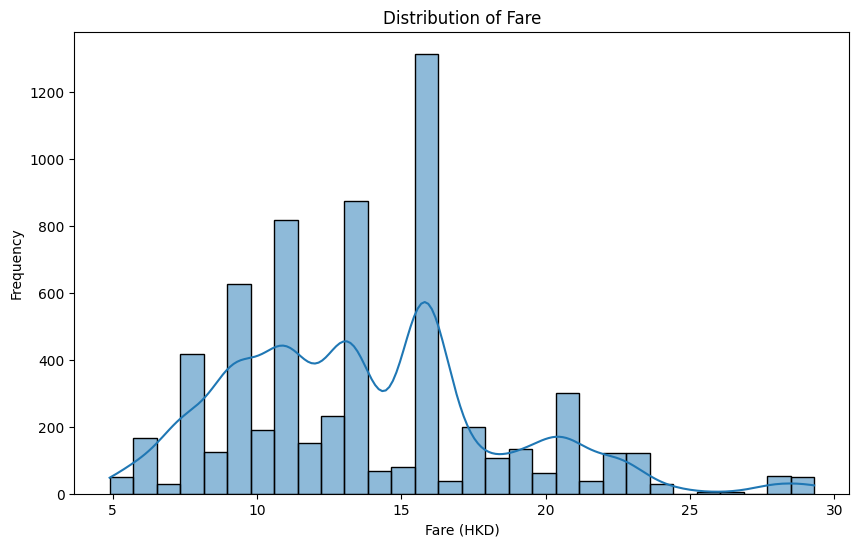

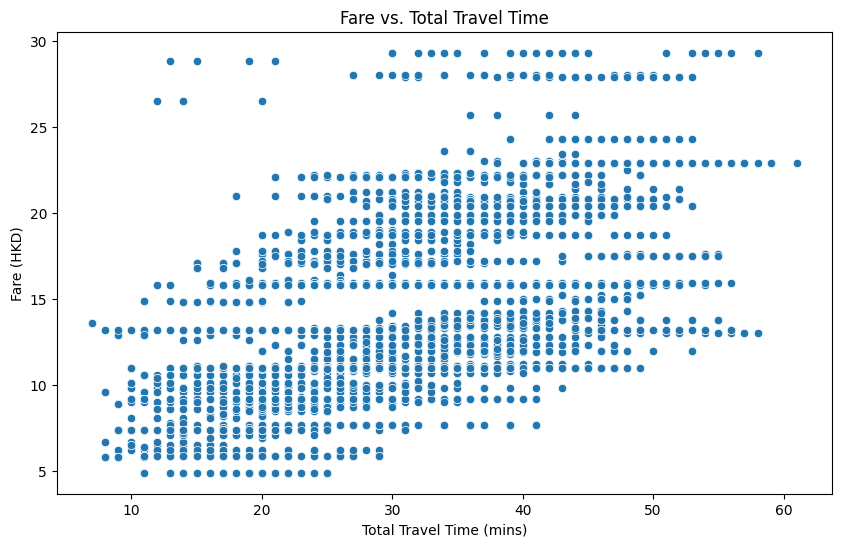

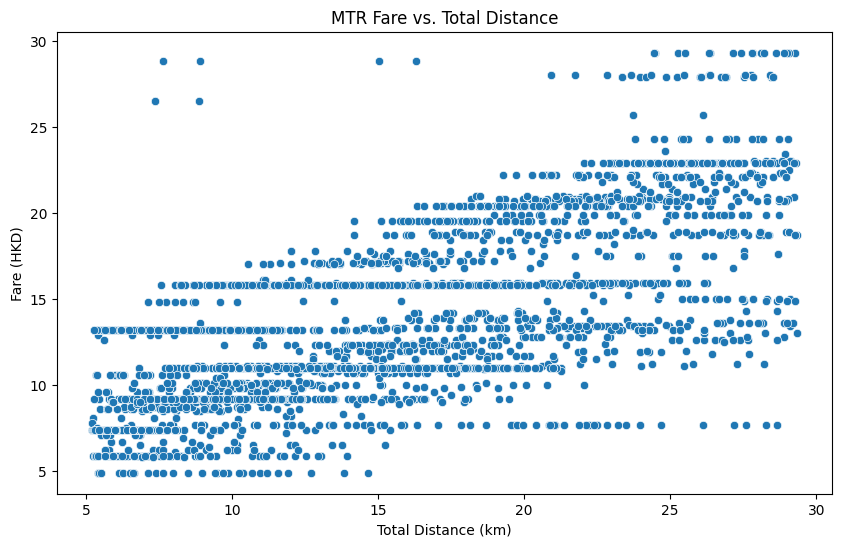

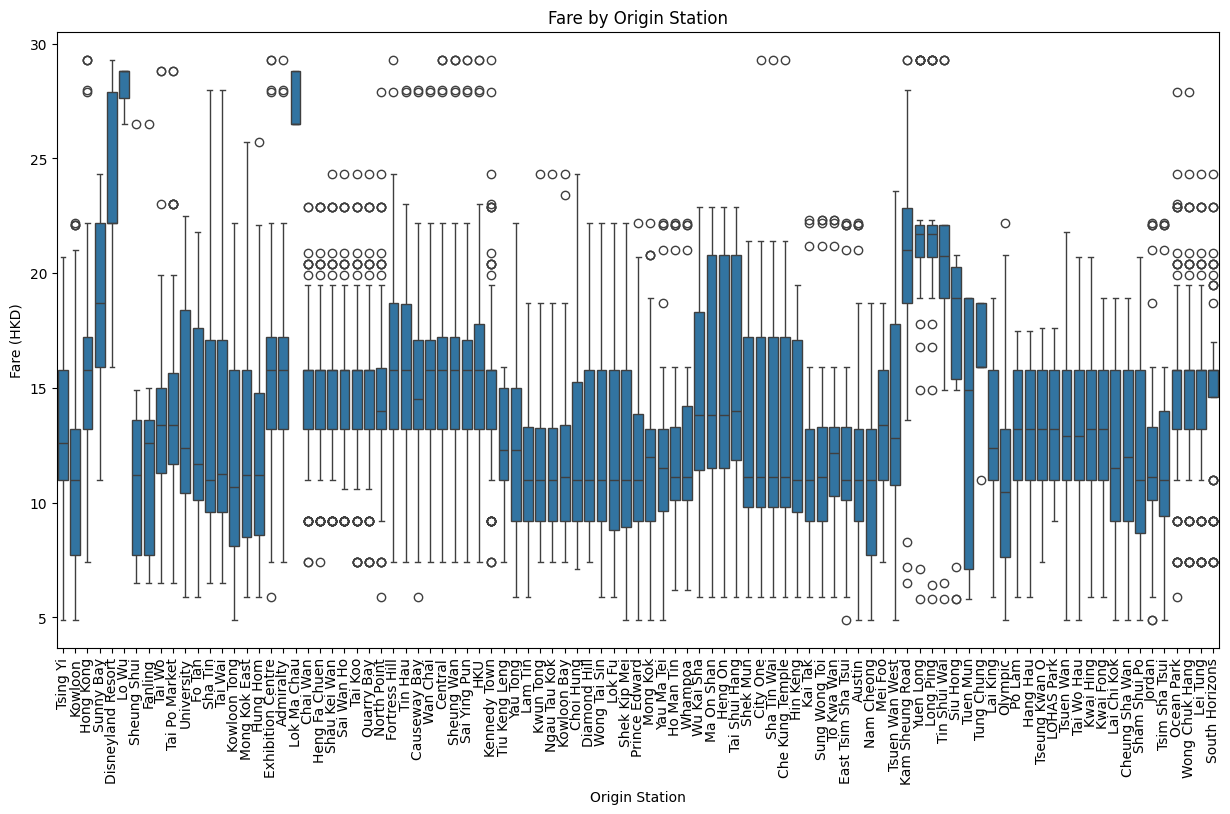

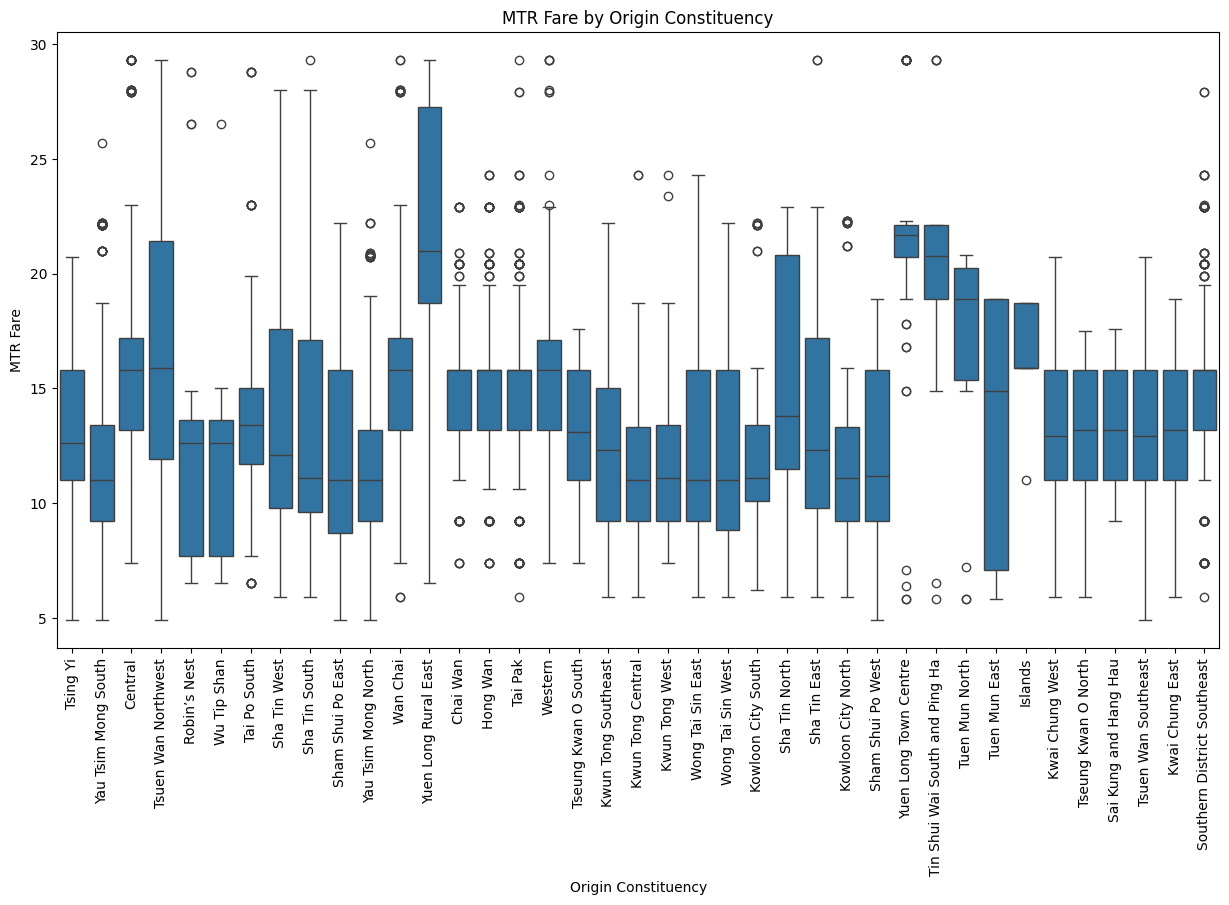

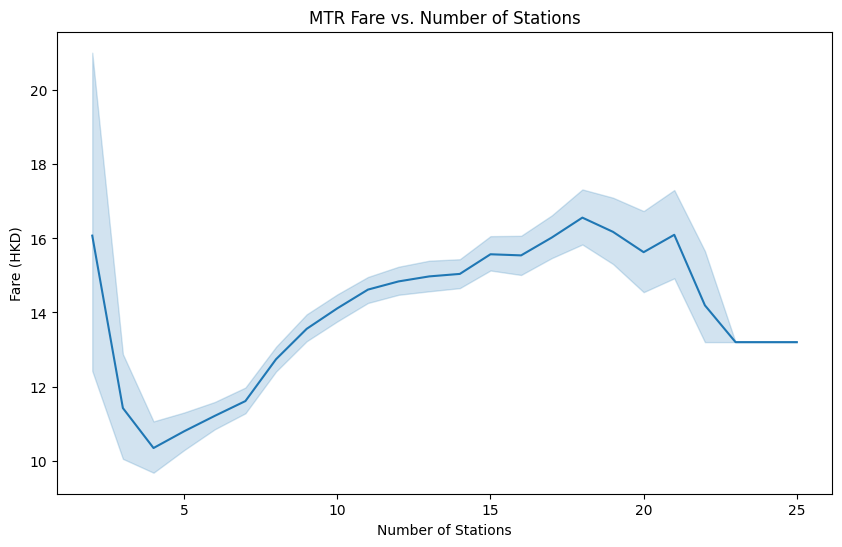

In [7]:
# Histogram of Fare Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['Fare (HKD)'], bins=30, kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare (HKD)')
plt.ylabel('Frequency')
plt.show()

# Scatter Plot of Fare vs. Total Travel Time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total Travel Time (mins)', y='Fare (HKD)', data=data)
plt.title('Fare vs. Total Travel Time')
plt.xlabel('Total Travel Time (mins)')
plt.ylabel('Fare (HKD)')
plt.show()

# Scatter Plot of Fare vs. Total Distance
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total Distance (km)', y='Fare (HKD)', data=data)
plt.title('MTR Fare vs. Total Distance')
plt.xlabel('Total Distance (km)')
plt.ylabel('Fare (HKD)')
plt.show()

# Box Plot of Fare by Origin Station
plt.figure(figsize=(15, 8))
sns.boxplot(x='Origin Station', y='Fare (HKD)', data=data)
plt.title('Fare by Origin Station')
plt.xlabel('Origin Station')
plt.ylabel('Fare (HKD)')
plt.xticks(rotation=90)
plt.show()

# Box Plot of Fare by Origin Constituency
## Note that for MTR data, fare by destination constituency is same as fare by origin constituency 
plt.figure(figsize=(15, 8))
sns.boxplot(x='Origin Constituency', y='Fare (HKD)', data=data)
plt.title('MTR Fare by Origin Constituency')
plt.xlabel('Origin Constituency')
plt.ylabel('MTR Fare')
plt.xticks(rotation=90)
plt.show()

# Line Plot of Fare vs. Number of Stations 
plt.figure(figsize=(10, 6))
sns.lineplot(x='No. of Stations', y='Fare (HKD)', data=data)
plt.title('MTR Fare vs. Number of Stations')
plt.xlabel('Number of Stations')
plt.ylabel('Fare (HKD)')
plt.show()

## 2. Fare distribution
## 2.1 Bar char

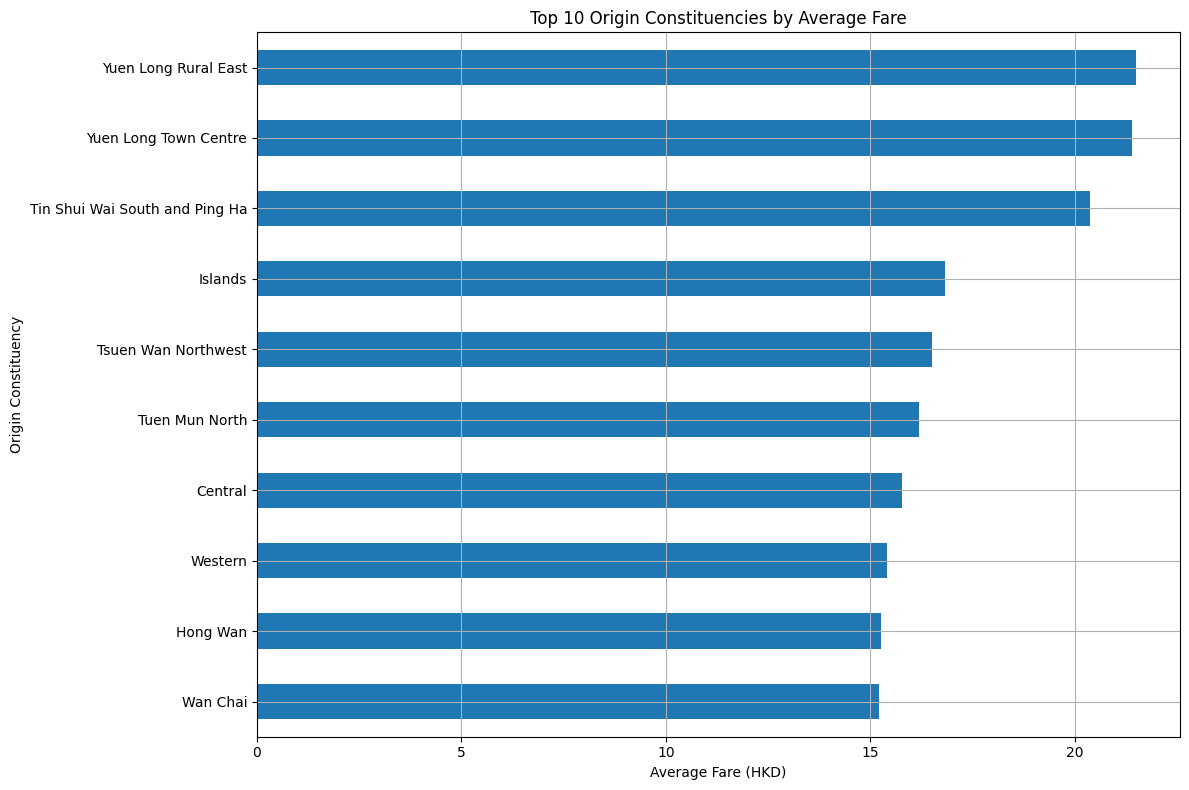

In [7]:
# Average Fare by Origin Constituency
avg_fare_by_district = data.groupby('Origin Constituency')['Fare (HKD)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
avg_fare_by_district.sort_values().plot(kind='barh')  # Use horizontal bar plot and sort values to have the highest fare at the top
plt.title('Top 10 Origin Constituencies by Average Fare')
plt.xlabel('Average Fare (HKD)')
plt.ylabel('Origin Constituency')
plt.grid(True)
plt.tight_layout()
plt.show()

## 2.2 Heatmap 

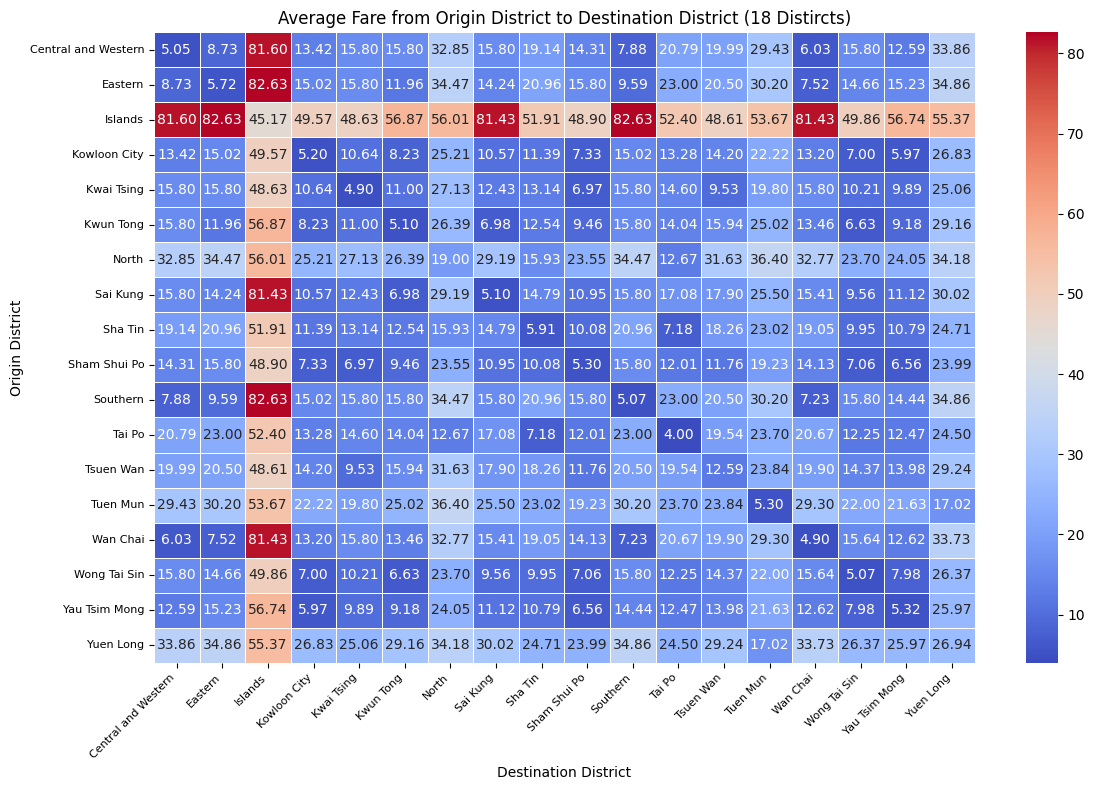

In [6]:
# Heatmap of Fare by Origin and Destination District
# Calculate the average fare between origin and destination districts
avg_fare_matrix = data.pivot_table(index='Origin District', columns='Destination District', values='Fare (HKD)', aggfunc='mean')

# Sort the index and columns to ensure correct label alignment
avg_fare_matrix = avg_fare_matrix.sort_index().sort_index(axis=1)

# Create a heatmap of the average fare between districts
plt.figure(figsize=(12, 8))
sns.heatmap(avg_fare_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Average Fare from Origin District to Destination District (18 Distircts)')
plt.xlabel('Destination District')
plt.ylabel('Origin District')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

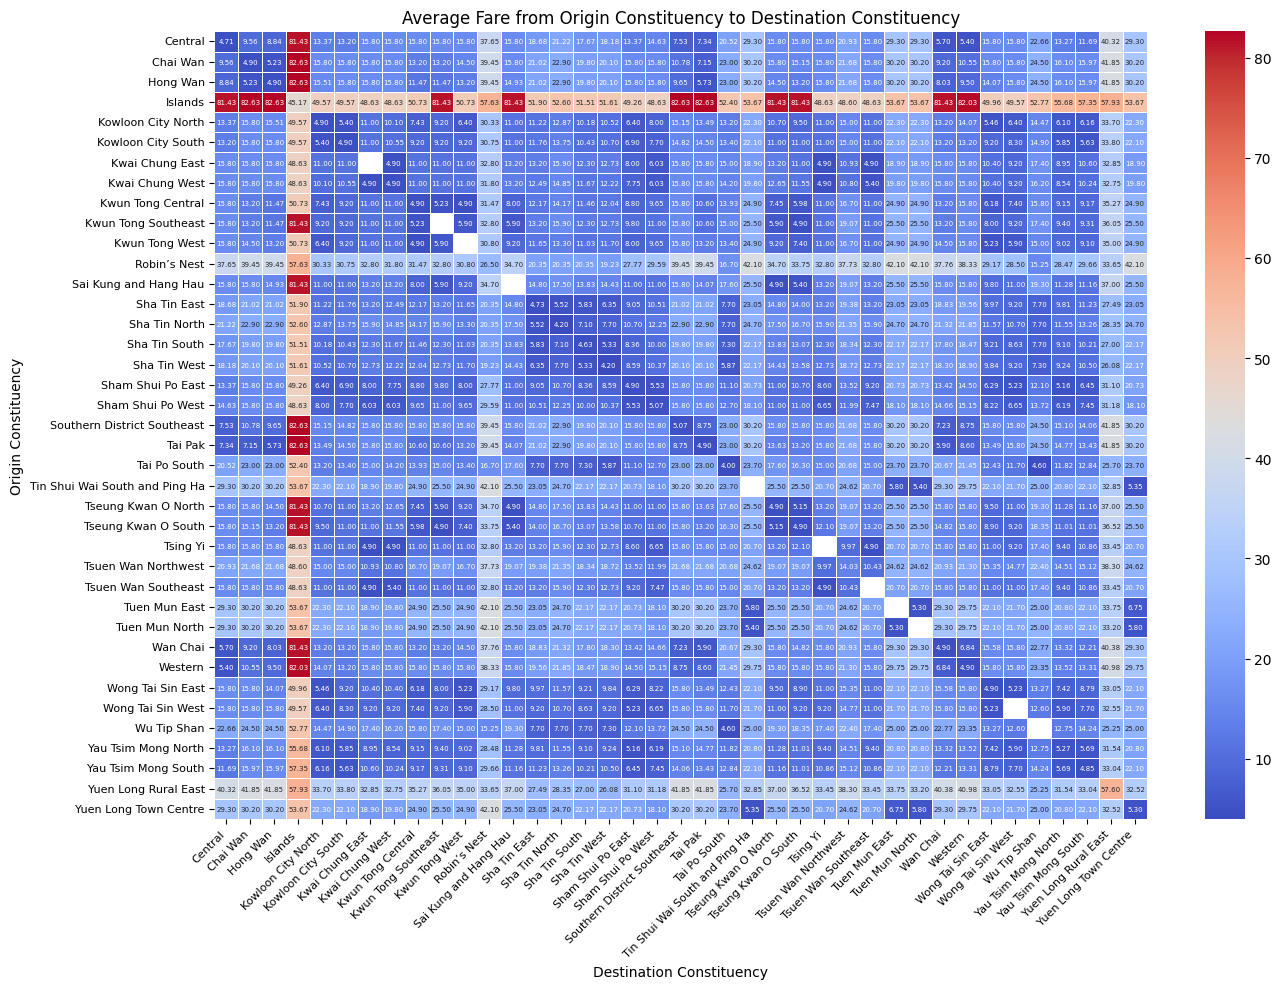

In [7]:
# Filter data based on origin district
hong_kong = ["Central and Western", "Eastern", "Southern", "Wan Chai"]
kowloon = ["Yau Tsim Mong", "Sham Shui Po", "Kowloon City", "Wong Tai Sin", "Kwun Tong"]
new_territories = ["Kwai Tsing", "Tsuen Wan", "Tuen Mun", "Yuen Long", "North", "Tai Po", "Sha Tin", "Sai Kung", "Islands"]

df_hong_kong = data[data['Origin District'].isin(hong_kong)]
df_kowloon = data[data['Origin District'].isin(kowloon)]
df_new_territories = data[data['Origin District'].isin(new_territories)]

# Calculate the average fare between origin and destination districts
avg_fare_matrix = data.pivot_table(index='Origin Constituency', columns='Destination Constituency', values='Fare (HKD)', aggfunc='mean')

# Sort the index and columns to ensure correct label alignment
avg_fare_matrix = avg_fare_matrix.sort_index().sort_index(axis=1)

# Create a heatmap of the average fare between districts
plt.figure(figsize=(14, 10))
sns.heatmap(avg_fare_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, annot_kws={"size": 5})
plt.title('Average Fare from Origin Constituency to Destination Constituency')
plt.xlabel('Destination Constituency')
plt.ylabel('Origin Constituency')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# Filter data based on origin district
hong_kong = ["Central and Western", "Eastern", "Southern", "Wan Chai"]
kowloon = ["Yau Tsim Mong", "Sham Shui Po", "Kowloon City", "Wong Tai Sin", "Kwun Tong"]
new_territories = ["Kwai Tsing", "Tsuen Wan", "Tuen Mun", "Yuen Long", "North", "Tai Po", "Sha Tin", "Sai Kung", "Islands"]

df_hong_kong = data[data['Origin District'].isin(hong_kong)]
df_kowloon = data[data['Origin District'].isin(kowloon)]
df_new_territories = data[data['Origin District'].isin(new_territories)]

# Define colors for each district
colors_hk = {'Central and Western': 'blue', 'Eastern': 'green', 'Southern': 'red', 'Wan Chai': 'purple'}
colors_kln = {'Yau Tsim Mong': 'blue', 'Sham Shui Po': 'green', 'Kowloon City': 'red', 'Wong Tai Sin': 'purple', 'Kwun Tong': 'orange'}
colors_nt = {'Kwai Tsing': 'blue', 'Tsuen Wan': 'green', 'Tuen Mun': 'red', 'Yuen Long': 'purple', 'North': 'orange', 'Tai Po': 'brown', 'Sha Tin': 'pink', 'Sai Kung': 'yellow', 'Islands': 'cyan'}

## 2.2.1 Heatmap: Hong Kong Area

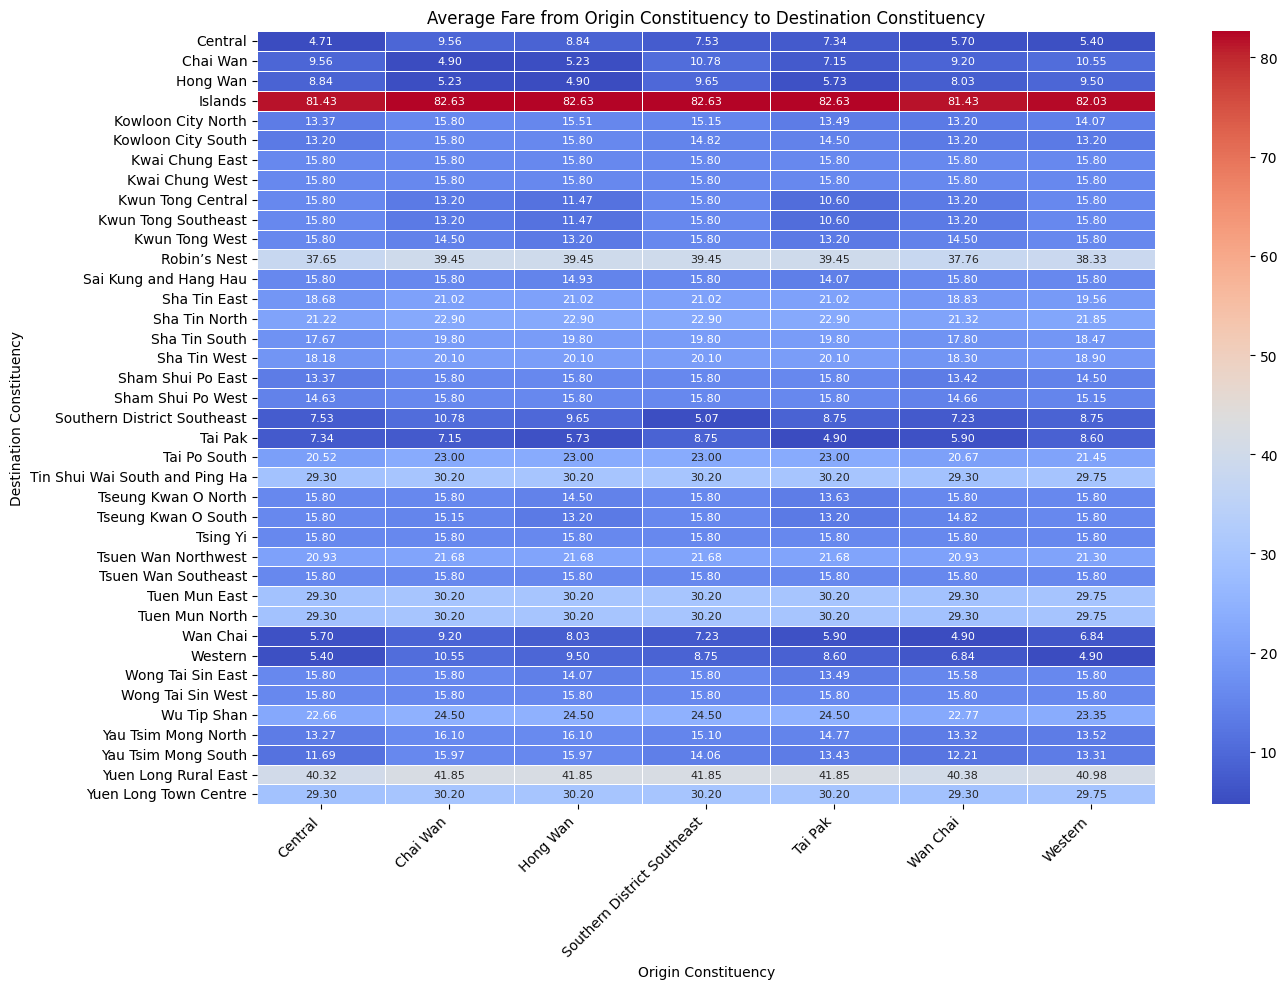

In [9]:
avg_fare_matrix = df_hong_kong.pivot_table(index='Destination Constituency', columns='Origin Constituency', values='Fare (HKD)', aggfunc='mean')

# Sort the index and columns to ensure correct label alignment
avg_fare_matrix = avg_fare_matrix.sort_index().sort_index(axis=1)

# Create a heatmap of the average fare between districts
plt.figure(figsize=(14, 10))
heatmap = sns.heatmap(avg_fare_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, annot_kws={"size": 8})
heatmap.set_title('Average Fare from Origin Constituency to Destination Constituency')
heatmap.set_xlabel('Origin Constituency')
heatmap.set_ylabel('Destination Constituency')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## 2.2.2. Heatmap: Kowloon Area

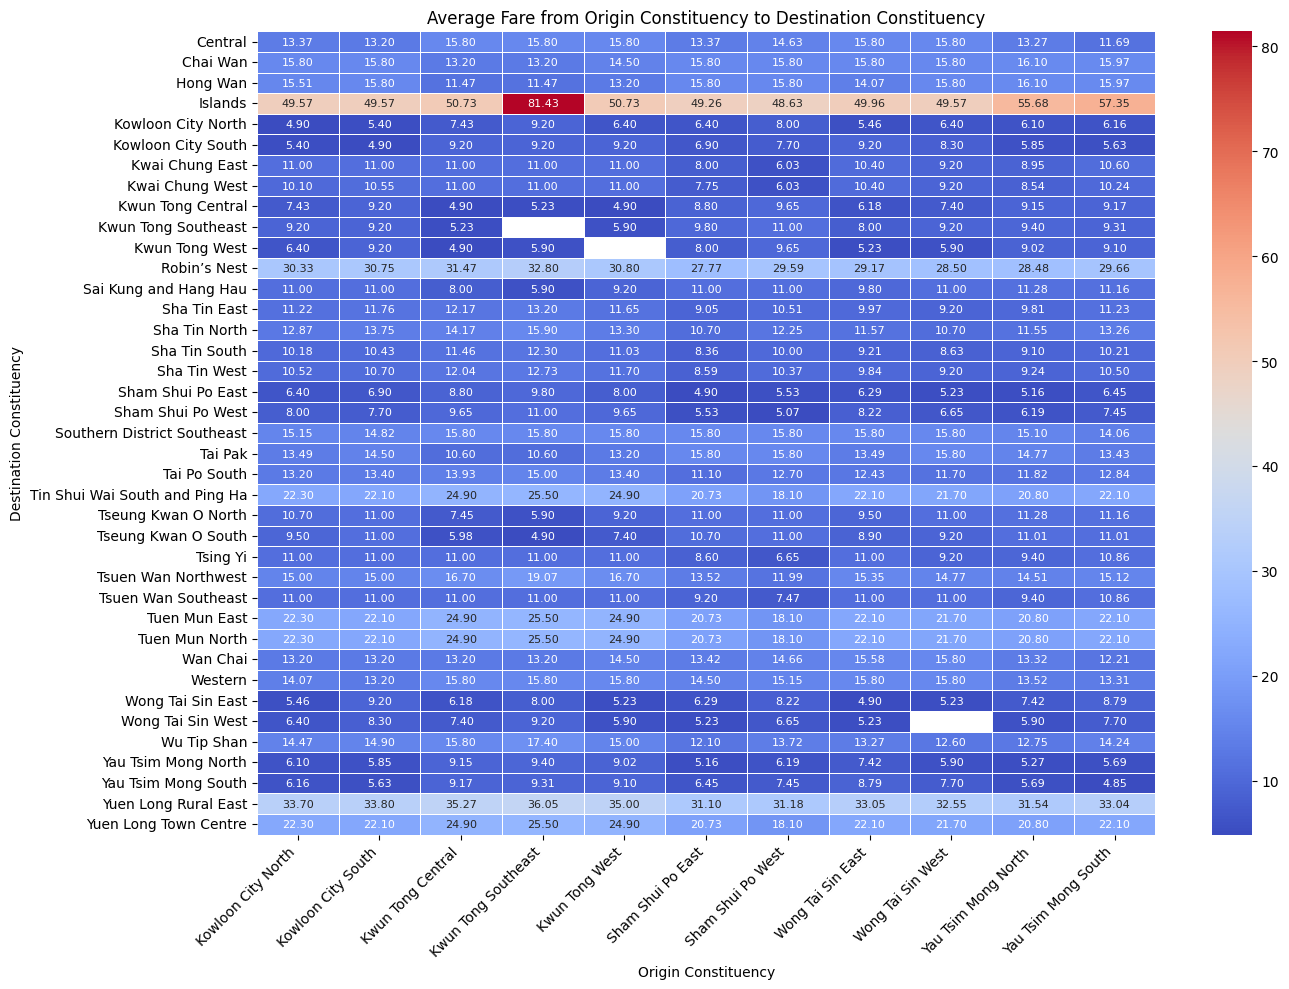

In [10]:
avg_fare_matrix = df_kowloon.pivot_table(index='Destination Constituency', columns='Origin Constituency', values='Fare (HKD)', aggfunc='mean')

# Sort the index and columns to ensure correct label alignment
avg_fare_matrix = avg_fare_matrix.sort_index().sort_index(axis=1)

# Create a heatmap of the average fare between districts
plt.figure(figsize=(14, 10))
heatmap = sns.heatmap(avg_fare_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, annot_kws={"size": 8})
heatmap.set_title('Average Fare from Origin Constituency to Destination Constituency')
heatmap.set_xlabel('Origin Constituency')
heatmap.set_ylabel('Destination Constituency')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## 2.2.3. Heatmap: New Territories Area

In [ ]:
avg_fare_matrix = df_new_territories.pivot_table(index='Destination Constituency', columns='Origin Constituency', values='Fare (HKD)', aggfunc='mean')

# Sort the index and columns to ensure correct label alignment
avg_fare_matrix = avg_fare_matrix.sort_index().sort_index(axis=1)

# Create a heatmap of the average fare between districts
plt.figure(figsize=(14, 10))
heatmap = sns.heatmap(avg_fare_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, annot_kws={"size": 8})
heatmap.set_title('Average Fare from Origin Constituency to Destination Constituency')
heatmap.set_xlabel('Origin Constituency')
heatmap.set_ylabel('Destination Constituency')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()